**Submitted by `your_name` on `date_of_submission`**

# Optimization Exercises

This notebook was written by Dr. Selin Ataç (selin.atac@epfl.ch), Dr. Léa Ricard (lea.ricard@epfl.ch), and Prunelle Vogler (prunelle.vogler@epfl.ch) for the Optimization and Simulation course at EPFL (https://edu.epfl.ch/studyplan/en/doctoral_school/civil-and-environmental-engineering/coursebook/optimization-and-simulation-MATH-600). 

Please contact before distributing or reusing the material below.

## Table of Contents
* [Online Knapsack Problem Beer Bar Example](#Online-Knapsack-Problem:-Beer-Bar-Example)
   * [Objective function](#Exercise-1-—-Objective-function)
   * [Improve policy](#Exercise-2-—-Improve-the-policy)
* [(Priced) Knapsack Problem](#(Priced)-Knapsack-problem)
   * [Problem definition and encoding](#Problem-definition-(KP))
   * [Implementation](#Implementation)
   * [Core functionalities](#The-core-functionalities)
* [Multi-objective optimization](#Multi-objective-optimization)
    * [Dominance](#Dominance)

## Online Knapsack Problem: Beer Bar Example

We consider an **online knapsack problem** inspired by a beer bar.

Time is **discretized**: at each time step $t = 1, 2, \dots, T$, exactly one client arrives.

Each client arriving at time $t$ is characterized by:

* a **demand** $d_t$ (number of beers requested),
* an **offer price** $c_t$ (amount (in CHF / beer) the client is willing to pay per beer if its request is accepted).

When a client arrives, the bartender must **immediately decide** whether to accept or reject the request of the client, knowing its demand and its offered price, without knowing future arrivals.



The objective is to **maximize the expected total profit** over the day by choosing an appropriate **accept/reject policy**.


Constraints:

* **Capacity constraint**: the total accepted demand cannot exceed the initial capacity $C$, which represents the number of bottle of beers available.
* **Finite horizon**: the process stops after $T$ time steps.


At time $t$, the decision maker observes:

* all past demands $d_1, \dots, d_{t-1}$,
* all past offered price $c_1, \dots, c_{t-1}$,
* all past accept/reject decisions,
* remaining capacity,
* current time $t$.

This information defines the **state of the system** at time $t$.
We represent it using the following class and we define the initial state at time $t = 0$.



In [10]:
class State:
    def __init__(self, t=0):
        self.t = t
        self.demands = []
        self.offers = []
        self.decisions = []

    def used_capacity(self):
        return sum(d for d, a in zip(self.demands, self.decisions) if a)

    def average_offer(self):
        if len(self.offers) == 0:
            return 0.0
        return sum(d * c for d, c in zip(self.demands, self.offers)) / sum(self.demands)
    
    def total_profit(self):
        return sum(
            d * c for d, c, a in zip(self.demands, self.offers, self.decisions) if a
        )


state = State(t=0)


A **policy** is a function that decides whether to accept or reject the current client.

```python
def accept_reject_policy(state, demand, offer, **params):
    """
    Returns True if the client is accepted, False otherwise.
    """
    pass
```

The policy:

* takes the current `state`,
* observes the incoming client `(demand, offer)`,
* may depend on additional parameters,
* returns a decision.


We first define a **simple policy**, the average-offer policy, based on the observed average offer so far.

Policy description:

* Let $\bar{c}_t$ be the average offer observed up to time $t$.
* The client is accepted if:
$$
  c \ge y \times \bar{c}_t
$$
where $y \in [0,1]$ is a policy parameter.

In [11]:
def accept_reject_policy_avg(state, demand, offer, capacity=100, T=1.0, y=1.0):
    # Reject if accepting would violate capacity
    if demand > capacity - state.used_capacity():
        return False
    
    avg_offer = state.average_offer()
    # Always accept the first client
    if avg_offer == 0:
        return True

    return offer >= y * avg_offer

### Exercise 1 — Objective function

For simplicity:

* time is discretized: one client arrives at each time step $t = 1, \dots, T$,
* the demand $d_t$ and offer $c_t$ are **drawn from uniform distributions** and are independent,
* draws are independent across time.

Specifically, assume:
$$
d_t \sim \mathcal{U}[d_{\min}, d_{\max}], \qquad
c_t \sim \mathcal{U}[c_{\min}, c_{\max}].
$$

**Task:** Complete the function `objective_function` below.

The function:

* takes as input a policy function, e.g., `accept_reject_policy_avg`,
* draws $(d_t, c_t)$ at each time step from uniform distributions,
* applies the policy,
* updates the system state,
* simulates $K$ independent days,
* returns the average total profit over these $K$ simulated days.


In [12]:
import random

def objective_function(
    accept_reject_policy,
    K,
    C,
    T,
    d_min,
    d_max,
    c_min,
    c_max,
    **policy_params
):
    """
    Simulates K days of operation and returns the average total profit.

    Parameters
    ----------
    accept_reject_policy : function
        Accept/reject policy (any policy with the correct signature).
    C : float
        Initial capacity.
    T : int
        Number of time steps.
    d_min, d_max : float
        Bounds of the uniform distribution for demand.
    c_min, c_max : float
        Bounds of the uniform distribution for offer.
    policy_params : dict
        Parameters passed to the policy.
    K : int
        Number of simulated days.

    Returns
    -------
    float
        Average total profit over the horizon.
    """
    avg_profit = []

    for _ in range(K):
        state = State(t=0)
        for t in range(1, T + 1):
            state.t = t

            # Draw a new client for the current day
            d_t = random.uniform(d_min, d_max)
            c_t = random.uniform(c_min, c_max)

            # Apply the policy
            accept = accept_reject_policy(
                state, d_t, c_t, capacity=C, T=T, **policy_params
            )

            # Update the state
            state.demands.append(d_t)
            state.offers.append(c_t)
            state.decisions.append(accept)

        avg_profit.append(state.total_profit())

    # Return the average profit over all simulated days
    return sum(avg_profit) / K


#### Test the function `objective_function`

In [13]:
profit_avg = objective_function(
    accept_reject_policy_avg,
    K = 1000,
    C=100,
    T=50,
    d_min=1,
    d_max=5,
    c_min=1,
    c_max=10,
    y=1.0
)

print(f"Profit with average payment policy: {profit_avg:.2f}")

Profit with average payment policy: 578.90


### Line search for the average-offer policy

This cell performs a line search over the parameter $y$ of the average-offer acceptance policy. For each value of $y$, the average profit is computed and plotted. This visualization helps you:

- Analyze how the threshold parameter $y$ affects the policy's performance.
- Identify the value of $y$ that maximizes the average profit.
- Understand the sensitivity of the policy to changes in $y$.

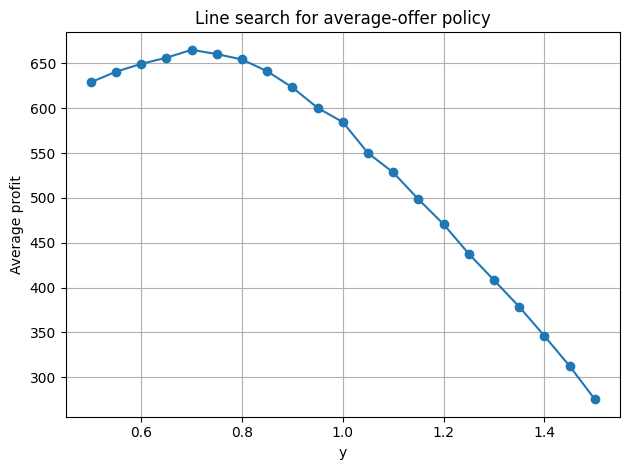

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Line search over y ---
y_vals = np.linspace(0.5, 1.5, 21)
profits = []

for y in y_vals:
    p = objective_function(
        accept_reject_policy_avg,
        K=1000,
        C=100,
        T=50,
        d_min=1,
        d_max=5,
        c_min=1,
        c_max=10,
        y=y,
    )
    profits.append(p)

profits = np.array(profits)

# --- Plot ---
plt.figure()
plt.plot(y_vals, profits, marker="o")
plt.xlabel("y")
plt.ylabel("Average profit")
plt.title("Line search for average-offer policy")
plt.grid(True)
plt.tight_layout()
plt.show()

### Exercise 1 — Improve the policy

The previous policy ignores the fact that **time is running out**.
Close to the end of the day, it may be optimal to accept lower-paying clients.

**Task**: Write a new policy accept_reject_policy_time that use a second parameter x in addition to parameter y to take into accound the time running out. Compare the two policy using the provided algorithm.

**Solution (other policies are possible)**:

In [15]:
def accept_reject_policy_time(state, demand, offer, capacity=100, T=1.0, y=0.8, x=0.8):
    # Reject if accepting would violate capacity
    if demand > capacity - state.used_capacity():
        return False

    avg_offer = state.average_offer()

    # If we are late in the horizon, accept any feasible client
    if state.t >= x * T:
        return True

    # Always accept the first client
    if avg_offer == 0:
        return True

    # Otherwise, apply the average-offer threshold
    return offer >= y * avg_offer


**Test**

In this cell, we evaluate the performance of the time-based acceptance policy by computing the average profit for a given set of parameters. The results allow you to compare this policy with the average-offer policy and analyze how the additional time parameter influences the decision-making process and the overall profit. Adjust the parameters to explore their impact and optimize the policy.

In [16]:
profit_time = objective_function(
    accept_reject_policy_time,
    K=1000,
    C=100,
    T=50,
    d_min=1,
    d_max=5,
    c_min=1,
    c_max=10,
    y=1.0,
    x=0.8,
)
print(f"Profit with time-based policy: {profit_time:.2f}")

Profit with time-based policy: 625.70


### Grid search over (x, y) parameters

This cell performs a grid search over the parameters $x$ and $y$ for the time-based acceptance policy. For each combination of $x$ (fraction of the time horizon) and $y$ (average-offer threshold), the average profit is computed and visualized as a heatmap. This allows you to:

- Explore how the policy's performance changes with different values of $x$ and $y$.
- Identify regions where the policy yields higher profits.
- Compare the influence of the time horizon and the offer threshold on the optimal decision-making strategy.

Adjust the ranges and step sizes for $x$ and $y$ to refine your analysis and find the best parameter settings for your application.

Best average profit: 662.25 for x = 1.00, y = 0.76


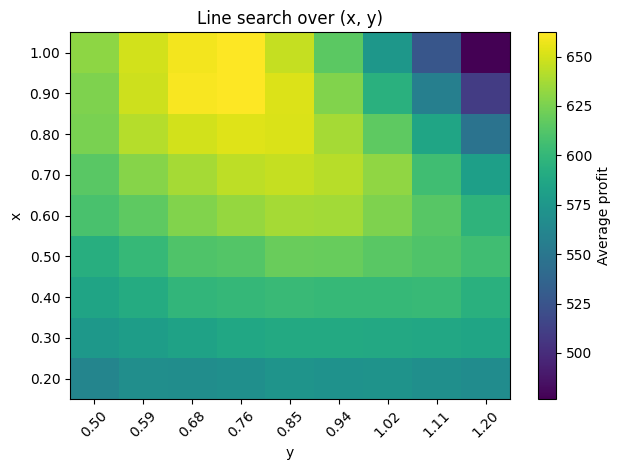

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Line search over x and y ---
x_vals = np.linspace(0.2, 1.0, 9)
y_vals = np.linspace(0.5, 1.2, 9)

results = np.zeros((len(x_vals), len(y_vals)))

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        results[i, j] = objective_function(
            accept_reject_policy_time,
            K=1000,
            C=100,
            T=50,
            d_min=1,
            d_max=5,
            c_min=1,
            c_max=10,
            x=x,
            y=y,
        )

# Find the best (x, y) and corresponding profit
best_idx = np.unravel_index(np.argmax(results), results.shape)
best_x = x_vals[best_idx[0]]
best_y = y_vals[best_idx[1]]
best_profit = results[best_idx]
print(f"Best average profit: {best_profit:.2f} for x = {best_x:.2f}, y = {best_y:.2f}")

# --- Plot ---
plt.figure()
plt.imshow(results, origin="lower", aspect="auto")
plt.colorbar(label="Average profit")
plt.xticks(range(len(y_vals)), [f"{y:.2f}" for y in y_vals], rotation=45)
plt.yticks(range(len(x_vals)), [f"{x:.2f}" for x in x_vals])
plt.xlabel("y")
plt.ylabel("x")
plt.title("Line search over (x, y)")
plt.tight_layout()
plt.show()

## (Priced) Knapsack problem

### Problem definition (KP)

Each item has a weight $w$, utility $u$ and cost $c$. What is the set of items that can be put in the knapsack that is below the maximum weigh, minimizes the cost, and maximizes the utility?

### Problem encoding

We consecutively number the items: $0,..., n$

We define our decision variables as $x_i=1$ if item $i$ is in knapsack, $0$ otherwise.

### Objectives

1. Maximizing the utility: $\max \mathcal{f}_1(x)=\sum_{i=1}^n u_i x_i$ 
2. Minimizing the cost: $\min \mathcal{f}_2(x)=\sum_{i=1}^n c_i x_i$
3. $w^Tx \leq W$ where $W$ is the maximum weight allowed, e.g. 100kg

### Implementation

#### The required python libraries
You will use the following python libraries in this exercise: `numpy`, `plotly`. Install it using `pip` on your command line:

    pip install numpy plotly

or if you are using conda:

    conda install numpy
    conda install -c plotly plotly

In [18]:
import numpy as np
import plotly
import plotly.graph_objects as go
import time

from numpy.random import Generator, PCG64 
from plotly.subplots import make_subplots

### The core functionalities

Next, we implement the objective functions `total_cost()`, `total_utility()`, and `weight()`:

In [19]:
def total_cost(sol, item_costs):
    """Function to implement

    Args:
        sol (list): a list of the all the decision variables x_1, ... x_n
        item_costs (list): a list of the cost c_1, ..., c_n of the items
        
    Returns:
        cost (float): total cost of the items in the knapsack
    
    """  
    cost = 0
    for i in range(len(sol)):
        cost += sol[i] * item_costs[i]
    return cost

def total_utility(sol, item_utilities):
    """Function to implement

    Args:
        sol (list): a list of the all the decision variables x_1, ... x_n
        item_utilities (list): a list of the utility u_1, ..., u_n of the items
        
    Returns:
        cost (float): total utility of the items in the knapsack
    
    """  
    utility = 0
    for i in range(len(sol)):
        utility += sol[i] * item_utilities[i]
    return utility

def weight(sol, item_weights):
    """Function to implement

    Args:
        sol (list): a list of the all the decision variables x_1, ... x_n
        item_weights (list): a list of the weight w_1, ..., w_n of the items
        
    Returns:
        cost (float): total weight of the items in the knapsack
    
    """ 
    weight = 0
    for i in range(len(sol)):
        weight += sol[i] * item_weights[i]
    return weight

#### Test the function `total_cost()`, `total_utility()`, and `weight()`

In [20]:
rg = Generator(PCG64(42069)) # set your own unique seed number
n_items = 5
item_weights = rg.integers(10, 50, n_items)
item_utilities = rg.integers(0, 100, n_items)
item_costs = rg.random(n_items)

print("weights: ", item_weights)
print("utility: ", item_utilities)
print("cost: ", item_costs)
sol = rg.integers(0, 2, n_items) # Random solution
print("Knapsack composition: ", sol)
print("Total cost: ", total_cost(sol, item_costs))
print("Total utility: ", total_utility(sol, item_utilities))
print("Total weight: ", weight(sol, item_weights))

weights:  [45 47 29 21 20]
utility:  [ 7 98 32 82 55]
cost:  [0.86346747 0.72134798 0.69142444 0.54085333 0.45354493]
Knapsack composition:  [1 1 0 0 0]
Total cost:  1.5848154561081227
Total utility:  105
Total weight:  92


# Multi-objective optimization

In this lab, we will implement a multi-objective optimization algorithm (described in the lecture notes). There are several methods are possible:

1. Weighted sum
2. Lexicographic rules (e.g. sequence by importance)
3. Constrained optimization
4. **Local search**/**heuristics**

Here, we will use a heurisric local search algorithm.



## Concepts in multi-objective optimization

- We need to minimize several objective functions.
- In many practical applications, the objectives are conflicting.
- Improving one objective may deteriorate several others (e.g., risk vs reward).

$$
min F(x) = (f_1(x), ..., f_p(x))
$$
subject to
$$
x \in F \subseteq \mathbb{R}^n
$$
where
$$
F: \mathbb{R}^n \rightarrow \mathbb{R}^p
$$

## Dominance

Notation:

$x_1$ dominates $x_2$: $F(x_1)\prec F(x_2)$

Dominance must fulfil two conditions, assuming we want to **minimize**

1. $x_1$ is no worse than $x_2$ in **any** objective: $\forall i \in \{1,...,p\},f_i(x_1)\leq f_i(x_2)$
2. $x_1$ is strictly better in at least one objective: $\exists i \in \{1,...,p\}, f_i(x_1)<f_i(x_2)$

### Pseudo algorithm for local search

(see lecture 8 notes, page 23)

Main difference with single objective optimization is that we need to maintain a set $P$ of potential Pareto optimal solutions such that 
$$ \forall x,y \in P, F(x) \nprec F(y)$$ and $$F(y) \nprec F(x). $$

**Initialization:**

Start with a first set $P$ of candidate solutions

**Main iteration:**

1. Select a random solution $x$ from $P$, define $x^+$ as a neighbour solution  
2. Define 2 sets: $D(x^+)$ and $S(x^+)$, where

$$D(x^+)=\{y\in P, s.t. F(x^+)\prec F(y)\}$$

$$S(x^+)=\{y\in P, s.t. F(y)\prec F(x^+)\}$$

In other words, at each iteration, compare each objective function of the new solution $x^+$ against all $y$ in $P$. If the condition is fulfiled for any of the above, put $y$ into the respective set.

3. If $S(x^+)=\emptyset$ (i.e., if $x^+$ is not dominated by any $y \in P$)
    
    Update $P$ (remove all exisiting solutions in the Pareto set, $P$, if it appears in $D$ and add the new solution to $P$):
$$
P^+ = P\cup \{x^+\} \setminus D(x^+)
$$

Implement the dominance conditions and compute the sets $D$ and $S$ in functions `dominance()` and `generate_D_and_S()`.

In [21]:
def dominance(cost_x1, cost_x2):
    """Function to implement
    Determines dominance between two solutions based on their cost components with respect to two objectives.

    Args:
        cost_x1 (list): a list of cost components with respect to objectives f_1 and f_2 for solution x1.
        cost_x2 (list): a list of cost components with respect to objectives f_1 and f_2 for solution x2.
        
    Returns:
        bool: True if solution x1 dominates solution x2, False otherwise.
        
    Examples:
        >>> dominance([105, 1.58], [99, 2.25])
        True
        >>> dominance([105, 1.58], [99, 1.45])
        False
    """ 
    
    strictly_better_one = False
    no_worst = True
    
    #Check first objective: Maximize utility
    if cost_x1[0] == cost_x2[0]:
        pass
    elif cost_x1[0] > cost_x2[0]:
        strictly_better_one = True
    else:
        no_worst = False

    #Check second objective: Maximize utility
    if cost_x1[1] == cost_x2[1]:
        pass
    elif cost_x1[1] < cost_x2[1]:
        strictly_better_one = True
    else:
        no_worst = False
        
    if strictly_better_one and no_worst: return True
    else: return False

def generate_D_and_S(P, cost_new, item_utilities, item_costs):
    
    """Function to implement
    Generates sets of solutions dominated and dominating a new neighbor solution within a Pareto set.

    Args:
        P (dict): a dictionary containing solutions in a Pareto set.
        cost_new (list): a list of cost components with respect to objectives f_1 and f_2 for a new neighbor 
                        solution.
        item_utilities (list): a list of the utility u_1, ..., u_n of the items.
        item_costs (list): a list of the cost c_1, ..., c_n of the items.

    Returns:
        D (dict): A set of solutions in P dominated by the new neighbor solution.
        S (dict): A set of solutions in P that dominate the new neighbor solution.
        
    """ 
        
    D = {}
    S = {}
    for key, sol in P.items():
        cost_sol = [total_utility(sol, item_utilities), total_cost(sol, item_costs)]
        if dominance(cost_new, cost_sol) == True or cost_new == cost_sol:
            D[key] = sol
        if dominance(cost_sol, cost_new) == True:
            S[key] = sol

    return D,S

### Neighbourhood structures.

Implement at least one neighborhood structure. Ensure that this neighborhood structure (or these neighborhood structures) enable(s) exploration of the Pareto frontier, from solutions with low costs and low utilities to solutions with high costs and high utilities. Ensure each neighborhood structure outputs feasible solutions by verifying that the total weight does not exceed the given maximum weight, $W$.

In [22]:
def neighborhood1(solution, item_weights, item_utilities, W):
    #Adds the item not in the bag with the highest utility. If there is sufficient space, keep all items
    # in the bag, if the weight limit is exceeded, randomly remove one item at a time.
    
    neighbor = solution.copy()
    
    highest_utility = 0
    item_highest_utility = None
    for i in range(len(item_weights)):
        if neighbor[i] == 0:
            if item_utilities[i] > highest_utility:
                highest_utility = item_utilities[i]
                item_highest_utility = i
    
    while weight(neighbor, item_weights) + item_weights[item_highest_utility] > W:
        neighbor[np.random.choice(neighbor)] = 0
    neighbor[item_highest_utility] = 1
    return neighbor

In [23]:
def neighborhood2(solution, item_costs):
    #Remove the item in the bag with the highest cost
    
    neighbor = solution.copy()
    
    highest_cost = 0
    item_highest_cost = None
    for i in range(len(item_costs)):
        if neighbor[i] == 1 and item_costs [i] > highest_cost:
            highest_cost = item_costs[i]
            item_highest_cost = i
    if item_highest_cost != None: neighbor[item_highest_cost] = 0
    return neighbor

### Main loop


Generate an initial random solution and add it to P. For example, start with 2 random items from the set.


Main iteration

    a. Select a random solution from set $P$
    b. Find neighbor(s)
    c. Compute the new cost of the new solution(s)
    d. Compute the Pareto dominance, i.e., sets $D$ and $S$
    e. If $S$ is empty, update $P$

        

In [24]:
def main(item_weights, item_utilities, item_costs, iterations=100, W=400):
    """Function to implement

    Args:
        item_weights (list): a list of the weight w_1, ..., w_n of the items
        item_utilities (list): a list of the utility u_1, ..., u_n of the items.
        item_costs (list): a list of the cost c_1, ..., c_n of the items.
        iterations (int): maximum number of iterations of the algorith
        W (int): maximumweight of the knapsack.

    Returns:
        P (dict): a dictionary containing solutions in a Pareto set.
        D_all (dict): a dictionary containing all dominated solutions.
        
    """ 
    
    P = {}
    D_all = {}
    P["s" + str(0)] = [1, 1] + [0] * (len(item_weights) - 2) # Initialize P with the first two items
    
    for i in range(iterations):
        P_list = list(P.keys())
        random_P = np.random.choice(P_list)
        solution = P[random_P]
        
        #First neighborhood structure
        neighbor1 = neighborhood1(solution, item_weights, item_utilities, W)
        cost_new1 = [total_utility(neighbor1, item_utilities), total_cost(neighbor1, item_costs)]
        D, S = generate_D_and_S(P, cost_new1, item_utilities, item_costs)
        D_all.update(D)
        
        if not S: 
            P_prime = {}
            for key1, solution1 in P.items():
                in_D = False
                for key2, solution2 in D.items():
                    if key2 == key1:
                        in_D = True
                if not in_D: P_prime[key1] = solution1
            P_prime["s" + str(i) + "_1"] = neighbor1
            P = P_prime
        
        #Second neighborhood structure
        neighbor2 = neighborhood2(solution, item_costs)
        cost_new2 = [total_utility(neighbor2, item_utilities), total_cost(neighbor2, item_costs)]
        D, S = generate_D_and_S(P, cost_new2, item_utilities, item_costs)
        D_all.update(D)
        
        if not S: 
            P_prime = {}
            for key1, solution1 in P.items():
                in_D = False
                for key2, solution2 in D.items():
                    if key2 == key1:
                        in_D = True
                if not in_D: P_prime[key1] = solution1
            P_prime["s" + str(i) + "_2"] = neighbor2
            P = P_prime
    
    #Remove redundant solutions in D
    redundant_keys = []
    for key1, sol1 in D_all.items():
        for sol2 in P.values():
            if sol1 == sol2:
                redundant_keys.append(key1)
                break  # Break out of inner loop once a redundant solution is found
    for key in redundant_keys:
        D_all.pop(key)
    
    return P, D_all

### Run the optimization

In [25]:
rg = Generator(PCG64(42069)) # set your own unique seed number
n_items = 20
item_weights = rg.integers(10, 50, n_items)
item_utilities = rg.integers(0, 100, n_items)
item_costs = rg.random(n_items)
P, D_all = main(item_weights, item_utilities, item_costs, iterations=1000, W=300) # weight limit=W

### View the Pareto frontier

In [26]:
def draw_pareto_frontier(P, D_all):
    costs_P = []
    utilities_P = []
    costs_D = []
    utilities_D = []

    for key, sol in P.items():
        cost = total_cost(sol, item_costs)
        costs_P.append(cost)
        utility = total_utility(sol, item_utilities)
        utilities_P.append(utility)

    for key, sol in D_all.items():
        cost = total_cost(sol, item_costs)
        costs_D.append(cost)
        utility = total_utility(sol, item_utilities)
        utilities_D.append(utility)

    trace_P = go.Scatter(x=utilities_P, y=costs_P, mode='markers', name='Non-dominated')
    trace_D = go.Scatter(x=utilities_D, y=costs_D, mode='markers', name='Dominated', marker=dict(symbol='x'))

    layout = go.Layout(
        template="presentation",
        xaxis=dict(title='Utility'),
        yaxis=dict(title='Cost'),
        legend=dict(x=0, y=1),
        width=800, 
        height=600
    )

    fig = go.Figure(data=[trace_P, trace_D], layout=layout)
    fig.show()

#### Run the function `draw_pareto_frontier()`

In [29]:
draw_pareto_frontier(P, D_all)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Further exercises

Try to implement a full enumaration algorithm. Use the `itertools.product()` function to generate all possible solutions. Apply dominance conditions. 

Calculate the computational time and limitations of the full enumeration.

What is the maximum problem size (number of items) that you could solve with this approach?

In [30]:
from itertools import product

In [31]:
def knapsack_fe(item_weights, item_utilities, item_costs, W=400):
    """Function to implement

    Args:
        item_weights (list): a list of the weight w_1, ..., w_n of the items
        item_utilities (list): a list of the utility u_1, ..., u_n of the items.
        item_costs (list): a list of the cost c_1, ..., c_n of the items.
        W (int): maximumweight of the knapsack.

    Returns:
        P (dict): a dictionary containing solutions in a Pareto set.
        D_all (dict): a dictionary containing all dominated solutions.
        
    """ 
    
    P = {}
    D_all = {}
    P["s" + str(0)] = [1, 1] + [0] * (len(item_weights) - 2) # Initialize P with the first two items
    i = 0

    all_lists = list(product([0, 1], repeat=len(item_weights)))
    
    for sol in all_lists:
        if weight(sol, item_weights) > W:
            all_lists.remove(sol)
        else:
            cost_sol = [total_utility(sol, item_utilities), total_cost(sol, item_costs)]
            D, S = generate_D_and_S(P, cost_sol, item_utilities, item_costs)
            D_all.update(D)
            if not S: 
                P_prime = {}
                for key1, solution1 in P.items():
                    in_D = False
                    for key2, solution2 in D.items():
                        if key2 == key1:
                            in_D = True
                    if not in_D: P_prime[key1] = solution1
                P_prime["s" + str(i)] = sol
                P = P_prime
                i += 1
            
    #Remove redundant solutions in D
    redundant_keys = []
    for key1, sol1 in D_all.items():
        for sol2 in P.values():
            if sol1 == sol2:
                redundant_keys.append(key1)
                break  # Break out of inner loop once a redundant solution is found
    for key in redundant_keys:
        D_all.pop(key)
    
    return P, D_all

In [ ]:
P_fe, D_all_fe = knapsack_fe(item_weights, item_utilities, item_costs, W=300) # weight limit=W
draw_pareto_frontier(P_fe, D_all_fe)

In [ ]:
draw_pareto_frontier(P_fe, D_all_fe)